Step 1: Teaching the computer using your existing data...


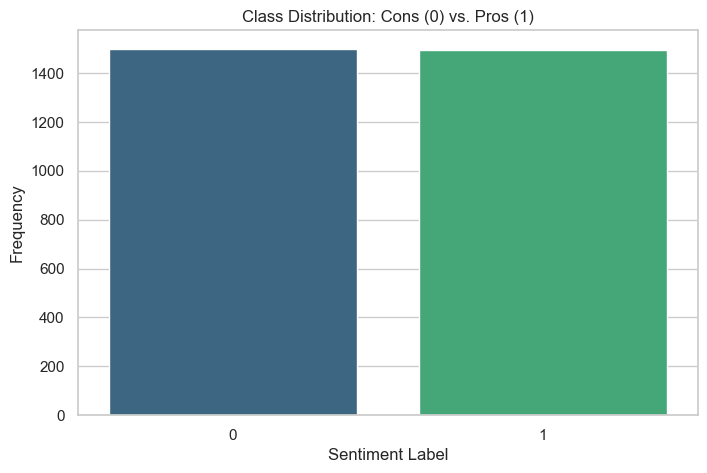

Vectorizing text data...
Training models...


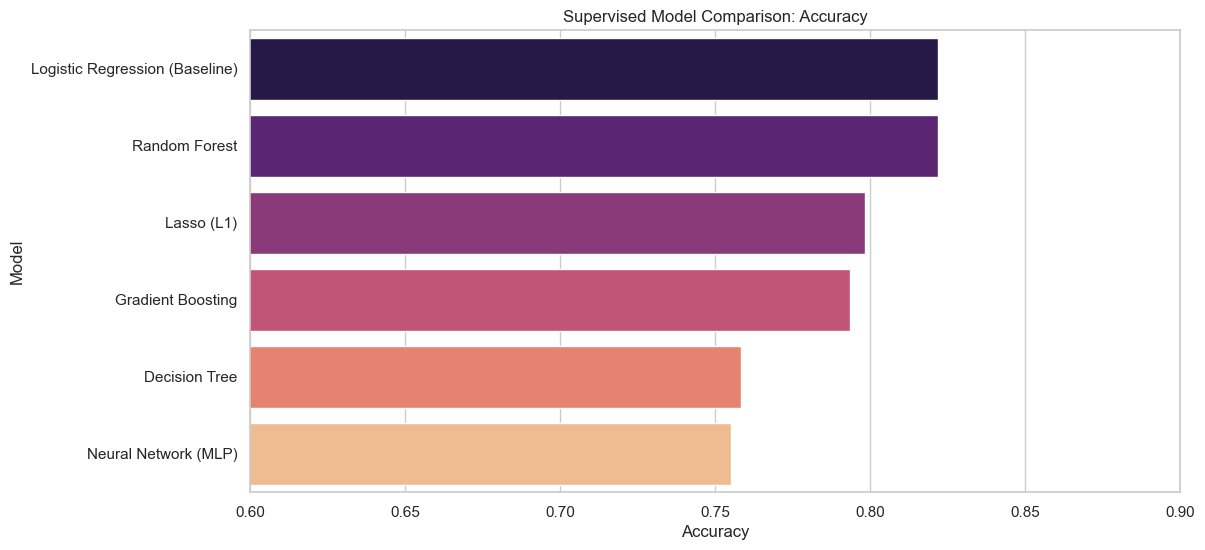


--- Model Performance Summary ---
                         Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression (Baseline)  0.821667   0.812950 0.804270  0.808587
                 Random Forest  0.821667   0.829545 0.779359  0.803670
                    Lasso (L1)  0.798333   0.841880 0.701068  0.765049
             Gradient Boosting  0.793333   0.894472 0.633452  0.741667
                 Decision Tree  0.758333   0.748175 0.729537  0.738739
          Neural Network (MLP)  0.755000   0.723333 0.772242  0.746988

Performing dimensionality reduction and clustering...


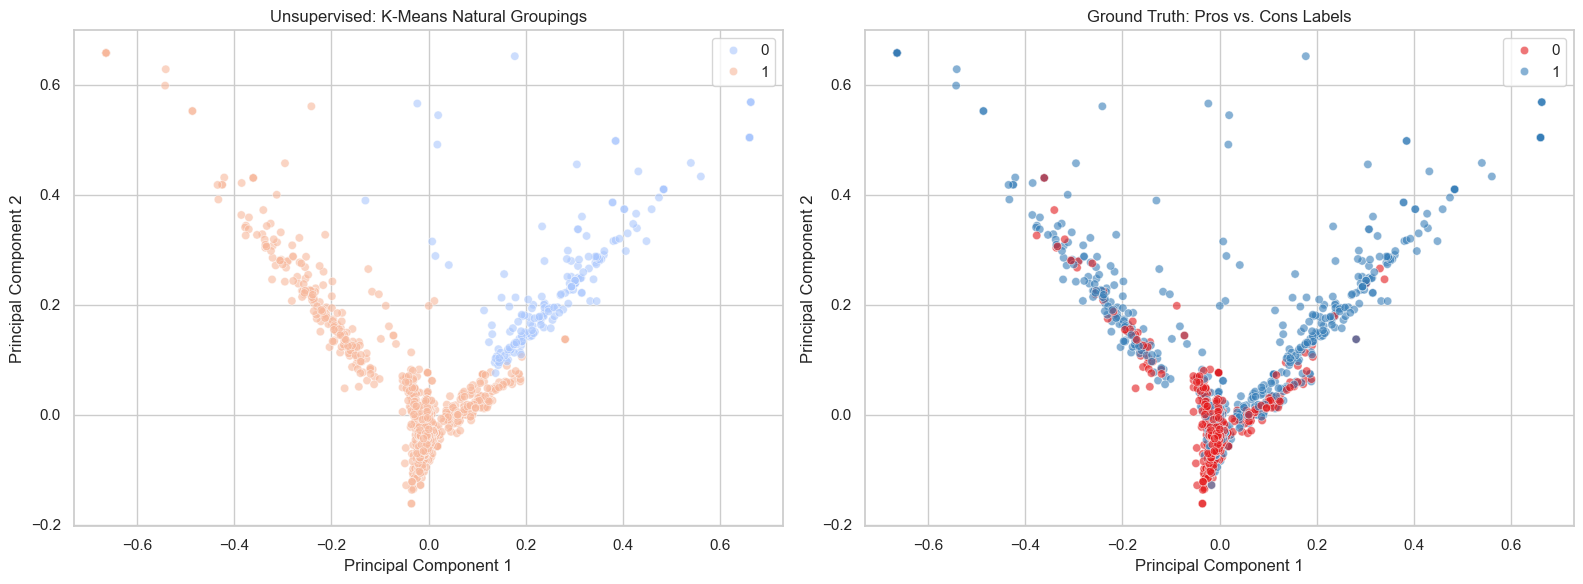


Process Complete. All plots and results generated.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import warnings

# We turn off "warnings" so the screen doesn't get cluttered with minor technical alerts
# Setup
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# =========================================================
# STEP 1: PREPARING THE TEACHING DATA
# =========================================================
# Think of this as giving the computer a textbook to study from.
# We load a file that already has sentences labeled as 1 (Pro) or 0 (Con).
print("Step 1: Teaching the computer using your existing data...")
# =========================================================
#   LOAD AND CLEAN TRAINING DATA
# =========================================================
# The dataset 'CapstoneDataSet.csv' is used to train the model
# We use 'utf-8' encoding to make sure we don't crash on special symbols like emojis or math signs
df = pd.read_csv('C:/Users/lubna/OneDrive/Desktop/Capstone Project Code/CapstoneDataSet.csv', header=None, names=['text', 'label'], encoding='utf-8')

# We remove any empty rows so the computer doesn't get confused by "blank" information
# Drop rows with missing labels and convert to integer
df = df.dropna()
# We make sure the "Pro/Con" labels are numbers (0 or 1) so the computer can do math with them
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna().reset_index(drop=True)
df['label'] = df['label'].astype(int)

# 2. EDA: CLASS DISTRIBUTION
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Class Distribution: Cons (0) vs. Pros (1)')
plt.xlabel('Sentiment Label')
plt.ylabel('Frequency')
plt.savefig('class_distribution.png')
plt.show()

# =========================================================
#   TURNING WORDS INTO MATH
# =========================================================
# Computers don't understand words; they understand numbers.
# This "Vectorizer" counts how important each word is and turns sentences into a list of numbers.
# 3. FEATURE ENGINEERING (TF-IDF)
# ---------------------------------------------------------
print("Vectorizing text data...")
# This "Vectorizer" counts how important each word is and turns sentences into a list of numbers.
tfidf = TfidfVectorizer(stop_words='english', max_features=1500)
X = tfidf.fit_transform(df['text']).toarray()
y = df['label'].values

# We split the data: 80% for teaching the computer, and 20% to test if it actually learned.
# Split data for supervised learning
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# =========================================================
#   TRAINING THE BRAIN (THE MODEL)
# =========================================================
# =========================================================
#   MODEL TRAINING AND COMPARISON FOR DIFFERENT MODELS
# =========================================================
# 4. SUPERVISED LEARNING: MODEL COMPARISON
# ---------------------------------------------------------
print("Training models...")
models = {
    "Logistic Regression (Baseline)": LogisticRegression(random_state=42),
    "Lasso (L1)": LogisticRegression(penalty='l1', solver='liblinear', random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

# =========================================================
# STEP 5: VISUALIZING WHICH MODEL DID BEST
# =========================================================
# Plot Model Comparison
plt.figure(figsize=(12, 6))
# This section creates a bar chart to compare our different "brains" (models).
# We create a bar for each model's accuracy so we can see who won at a glance.
sns.barplot(data=results_df, x='Accuracy', y='Model', palette='magma')
# We add a title and set the boundaries of the chart to make it easy to read.
plt.title('Supervised Model Comparison: Accuracy')
plt.xlim(0.6, 0.9) # We focus on the 60% to 90% range to see the differences clearly.
# Save the picture so we can put it in our report later.
plt.savefig('model_comparison.png')
plt.show()
# Print the actual numbers in the console for the "Pro vs Con" report.
print("\n--- Model Performance Summary ---")
print(results_df.to_string(index=False))

# =========================================================
# STEP 6: FINDING HIDDEN PATTERNS (UNSUPERVISED LEARNING)
# =========================================================
# Here, we ask the computer to find patterns on its own, without looking at our "Pro/Con" labels.
# 6. UNSUPERVISED LEARNING: PCA & K-MEANS
# ---------------------------------------------------------
print("\nPerforming dimensionality reduction and clustering...")
# PCA: Think of this as taking a 3D object and looking at its shadow on a 2D wall.
# It simplifies complex data into two main "features" so we can draw it on a flat graph.
# PCA to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# K-Means: This is like asking the computer to sort a messy pile of laundry into 2 piles
# based only on how the fabric feels, without knowing which pile is "Shirts" or "Pants."
# K-Means clustering (K=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# =========================================================
# STEP 7: COMPARING COMPUTER GUESSES VS. REALITY
# =========================================================
# We create a side-by-side picture to see if the computer's "blind" sorting matches the "real" labels.
# Visualize Clusters
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: This shows the 2 piles the computer made all by itself (K-Means).
# Plot 1: K-Means Clusters
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='coolwarm', alpha=0.6, ax=ax[0])
ax[0].set_title('Unsupervised: K-Means Natural Groupings')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

# Plot 2: This shows where the "Real" Pros and Cons actually sit.
# Plot 2: True Labels
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', alpha=0.6, ax=ax[1])
ax[1].set_title('Ground Truth: Pros vs. Cons Labels')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')

# Final formatting to make sure everything fits nicely.
plt.tight_layout()
plt.savefig('pca_clustering_comparison.png')
plt.show()

print("\nProcess Complete. All plots and results generated.")